### T1 
Use the Logistic Regression and Gaussian Naive Bayes algorithm to 
model data generated by the make_classification function in Python. 

Construct data sets with:

#### a) 100 samples, 1 feature and 2 classes

In [70]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt # MATLAB-like way of plotting
# sklearn package for machine learning in python:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from matplotlib.colors import ListedColormap


In [71]:
def plot_decision_boundary(model, X, y, title):
    # Create a mesh grid
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 500),
        np.linspace(y_min, y_max, 500)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid)
    Z = Z.reshape(xx.shape)

    # Custom colormap
    cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
    cmap_bold = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])

    # Plot
    plt.figure(figsize=(6, 5))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=cmap_light)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_bold, edgecolor='k')
    plt.title(title)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.tight_layout()
    plt.show()


In [72]:
def experiment(n_samples, n_features, n_classes, plot=False):

    # Dynamically determine valid n_informative
    n_clusters_per_class = 1
    required_informative = int(np.ceil(np.log2(n_classes * n_clusters_per_class)))
    n_informative = min(n_features, required_informative)
    
    X, y = make_classification(n_samples=n_samples, n_features=n_features, 
                               n_redundant=0, n_informative = n_informative, n_classes=n_classes, 
                               n_clusters_per_class=n_clusters_per_class, flip_y=0.4, random_state=42
                              )
    # split the data into training and test sets
    X_train, X_test, y_train, y_test = train_test_split(X, y,test_size= 1/3, random_state=42)

    
    # 3. Standardize features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    X_scaled = scaler.transform(X)  # full dataset (for plotting)


    #construct model and fit to the training data
    # 4. Train Logistic Regression
    logre = LogisticRegression(max_iter=1000)
    logre.fit(X_train_scaled, y_train)
    y_pred_logreg = logre.predict(X_test_scaled)


    # 5. Train Gaussian Naive Bayes
    gnb = GaussianNB()
    gnb.fit(X_train_scaled, y_train)
    y_pred_gnb = gnb.predict(X_test_scaled)


    # output the accuracy score
    print('LOGISTIC REGRESSION')
    print('Our Accuracy is %.2f' % logre.score(X_test_scaled, y_test))
    # output the number of mislabeled points
    print('Number of mislabeled points out of a total %d points : %d'% (X_test_scaled.shape[0], (y_test != logre.predict(X_test_scaled)).sum()))
    print('\n')


    

    # output the accuracy score
    print('GAUSSIAN NB')
    print('Our Accuracy is %.2f' % gnb.score(X_test, y_test))
    # output the number of mislabeled points
    print('Number of mislabeled points out of a total %d points : %d'% (X_test.shape[0], (y_test != gnb.predict(X_test)).sum()))
    print('\n')


    # 3D plot if 2D features
    if plot and n_features==1:
        # LR visualise the model
        print('LOGISTIC REGRESSION')
        fig1, ax1 = plt.subplots()
        ax1.scatter(X_test, y_test, color='blue')
        ax1.scatter(X_test, logre.predict(X_test), color='red', marker='*')
        ax1.scatter(X_test, logre.predict_proba(X_test)[:,1], color='green', marker='.')
        ax1.set_xlabel('X')
        ax1.set_ylabel('y')
        print('\n\n')

        # Gaus visualise the model
        print('GAUSSIAN NB')
        fig1, ax1 = plt.subplots()
        ax1.scatter(X_test, y_test, color='blue')
        ax1.scatter(X_test, gnb.predict(X_test), color='red', marker='*')
        ax1.scatter(X_test, gnb.predict_proba(X_test)[:,1], color='green', marker='.')
        ax1.set_xlabel('X')
        ax1.set_ylabel('y')
        print('\n\n\n')

    if plot and n_features==2:
        plot_decision_boundary(logre, X_scaled, y, "Logistic Regression Decision Boundary")
        plot_decision_boundary(gnb, X_scaled, y, "Gaussian Naive Bayes Decision Boundary")
       


LOGISTIC REGRESSION
Our Accuracy is 0.65
Number of mislabeled points out of a total 34 points : 12


GAUSSIAN NB
Our Accuracy is 0.65
Number of mislabeled points out of a total 34 points : 12


LOGISTIC REGRESSION



GAUSSIAN NB






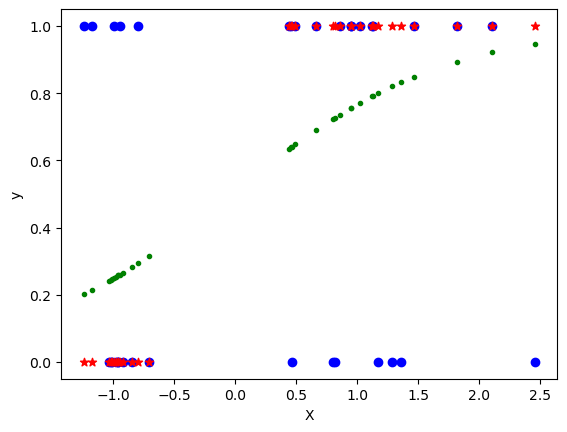

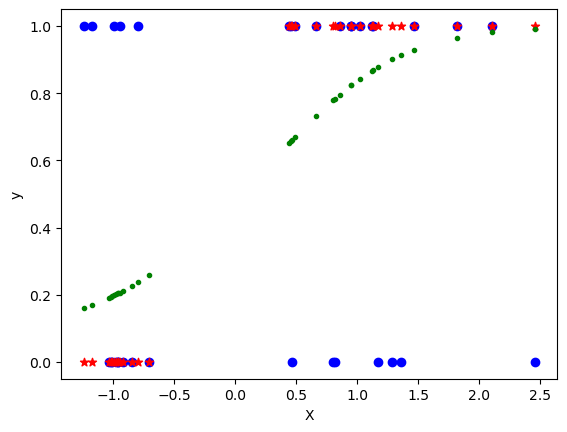

In [73]:
experiment(n_samples=100, n_features=1, n_classes=2, plot=True)

##### b) 400 samples, 1 feature and 2 classes

In [74]:
experiment(n_samples=200, n_features=1, n_classes=2, plot=False)

LOGISTIC REGRESSION
Our Accuracy is 0.81
Number of mislabeled points out of a total 67 points : 13


GAUSSIAN NB
Our Accuracy is 0.82
Number of mislabeled points out of a total 67 points : 12




### 500 samples, 2 features and 3 classes.

LOGISTIC REGRESSION
Our Accuracy is 0.60
Number of mislabeled points out of a total 167 points : 67


GAUSSIAN NB
Our Accuracy is 0.57
Number of mislabeled points out of a total 167 points : 71




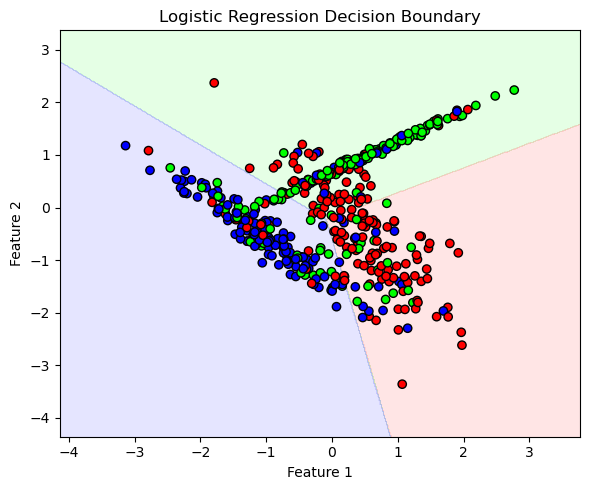

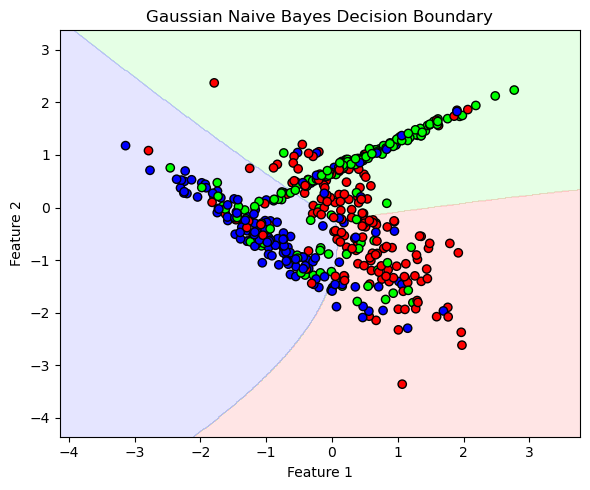

In [75]:
experiment(n_samples=500, n_features=2, n_classes=3, plot=True)

### d) 1000 samples, 8 features and 5 classes.

In [76]:
experiment(n_samples=1000, n_features=8, n_classes=5, plot=True)

LOGISTIC REGRESSION
Our Accuracy is 0.54
Number of mislabeled points out of a total 334 points : 155


GAUSSIAN NB
Our Accuracy is 0.52
Number of mislabeled points out of a total 334 points : 160


